In [ ]:
!pip -q install openpyxl xlrd

In [ ]:

import os
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

BASE_DIR = Path("/content")
OUTPUT_DIR = BASE_DIR / "outputs_iv_best_spec"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OPTION_FILE = BASE_DIR / "cny_options_2025_final.csv"
SPOT_FILE = BASE_DIR / "new_cny_rub_target_OHLC.csv"

RUONIA_CANDIDATES = [
    BASE_DIR / "RC_F01_01_2025_T31_12_2025.xlsx",
    BASE_DIR / "RC_F01_01_2025_T31_12_2025.xls",
]

SHIBOR_CANDIDATES = [
    BASE_DIR / "Shibor_Historical_Data.xlsx",
    BASE_DIR / "Shibor_Historical_Data.xls",
]

def first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError("Не найден ни один из файлов: " + ", ".join(map(str, paths)))

RUONIA_FILE = first_existing(RUONIA_CANDIDATES)
SHIBOR_FILE = first_existing(SHIBOR_CANDIDATES)

print("OPTION_FILE:", OPTION_FILE)
print("RUONIA_FILE:", RUONIA_FILE)
print("SHIBOR_FILE:", SHIBOR_FILE)
print("SPOT_FILE:", SPOT_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)

def find_col(cols, variants):
    cols_list = list(cols)
    cols_lc = {str(c).strip().lower(): c for c in cols_list}
    for v in variants:
        v_lc = str(v).strip().lower()
        if v_lc in cols_lc:
            return cols_lc[v_lc]
    for v in variants:
        v_lc = str(v).strip().lower()
        for c in cols_list:
            c_lc = str(c).strip().lower()
            if v_lc == c_lc:
                return c
    for v in variants:
        v_lc = str(v).strip().lower()
        for c in cols_list:
            c_lc = str(c).strip().lower()
            if v_lc in c_lc:
                return c
    return None

def parse_date_series(s):
    x = pd.to_datetime(s, errors="coerce")
    if x.notna().sum() > 0:
        return x
    for fmt in ["%d.%m.%Y", "%d %b %Y", "%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y"]:
        x = pd.to_datetime(s, format=fmt, errors="coerce")
        if x.notna().sum() > 0:
            return x
    return pd.to_datetime(s, errors="coerce")

def parse_cnyp_code(code):
    if pd.isna(code):
        return {}
    s = str(code).upper().strip().replace(" ", "")
    m = re.match(r"^CNYP(\d{6})([CP])([EA])(\d+(?:[\.,]\d+)?)$", s)
    if not m:
        return {}
    ddmmyy, cp, ex_style, strike = m.groups()
    exp = pd.to_datetime(ddmmyy, format="%d%m%y", errors="coerce")
    strike = float(strike.replace(",", "."))
    return {
        "expiration_from_code": exp,
        "option_type_from_code": cp,
        "exercise_type_from_code": ex_style,
        "strike_from_code": strike,
    }

def metric_table(actual, pred):
    temp = pd.DataFrame({"actual": actual, "pred": pred}).dropna().copy()
    if temp.empty:
        return {
            "n": 0,
            "pearson_corr": np.nan,
            "spearman_corr": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "mse": np.nan,
            "bias": np.nan,
            "r2_like": np.nan,
            "qlike_var": np.nan,
        }
    a = temp["actual"].to_numpy(dtype=float)
    p = temp["pred"].to_numpy(dtype=float)
    err = p - a
    mse = np.mean(err ** 2)
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(mse)
    bias = np.mean(err)
    denom = np.sum((a - np.mean(a)) ** 2)
    r2_like = 1 - np.sum((a - p) ** 2) / denom if denom > 0 else np.nan
    a_var = a ** 2
    p_var = p ** 2
    mask = (a_var > 0) & (p_var > 0)
    qlike_var = np.mean(np.log(p_var[mask]) + a_var[mask] / p_var[mask]) if mask.sum() > 0 else np.nan
    return {
        "n": len(temp),
        "pearson_corr": pd.Series(a).corr(pd.Series(p), method="pearson"),
        "spearman_corr": pd.Series(a).corr(pd.Series(p), method="spearman"),
        "mae": mae,
        "rmse": rmse,
        "mse": mse,
        "bias": bias,
        "r2_like": r2_like,
        "qlike_var": qlike_var,
    }


OPTION_FILE: /content/cny_options_2025_final.csv
RUONIA_FILE: /content/RC_F01_01_2025_T31_12_2025.xlsx
SHIBOR_FILE: /content/Shibor_Historical_Data.xlsx
SPOT_FILE: /content/new_cny_rub_target_OHLC.csv
OUTPUT_DIR: /content/outputs_iv_best_spec


In [ ]:

raw_opt = pd.read_csv(OPTION_FILE)
raw_opt.columns = [str(c).strip() for c in raw_opt.columns]

secid_col = find_col(raw_opt.columns, ["secid_raw", "secid", "symbol", "security", "code"])
if secid_col is None:
    raise ValueError("Не найден столбец с кодом опциона. Проверь названия колонок в cny_options_2025_final.csv")

raw_opt["secid_raw"] = raw_opt[secid_col].astype(str).str.strip()
cnyp = raw_opt[raw_opt["secid_raw"].str.upper().str.startswith("CNYP", na=False)].copy()

parsed = cnyp["secid_raw"].apply(parse_cnyp_code).apply(pd.Series)
if not parsed.empty:
    cnyp = pd.concat([cnyp.reset_index(drop=True), parsed.reset_index(drop=True)], axis=1)

trade_date_col = find_col(cnyp.columns, ["trade_date", "date", "tradedate"])
if trade_date_col is None:
    raise ValueError("Не найден столбец trade_date/date в файле опционов.")
cnyp["trade_date"] = parse_date_series(cnyp[trade_date_col])

expiration_col = find_col(cnyp.columns, ["expiration_date", "expiry", "expiration", "maturity"])
if expiration_col is not None:
    cnyp["expiration_date"] = parse_date_series(cnyp[expiration_col])
else:
    cnyp["expiration_date"] = pd.NaT

if "expiration_from_code" in cnyp.columns:
    cnyp["expiration_date"] = cnyp["expiration_date"].fillna(cnyp["expiration_from_code"])

opt_type_col = find_col(cnyp.columns, ["option_type", "cp", "put_call", "type"])
if opt_type_col is not None:
    cnyp["option_type"] = cnyp[opt_type_col].astype(str).str.upper().str[0]
else:
    cnyp["option_type"] = np.nan

if "option_type_from_code" in cnyp.columns:
    cnyp["option_type"] = cnyp["option_type"].fillna(cnyp["option_type_from_code"])

strike_col = find_col(cnyp.columns, ["strike", "strike_price", "exercise_price"])
if strike_col is not None:
    cnyp["strike"] = pd.to_numeric(cnyp[strike_col], errors="coerce")
else:
    cnyp["strike"] = np.nan

if "strike_from_code" in cnyp.columns:
    cnyp["strike"] = cnyp["strike"].fillna(cnyp["strike_from_code"])

for new_name, variants in {
    "settle_price": ["settle_price", "settle", "settleprice", "settle_prc", "settlprice"],
    "last_trade_price": ["last_trade_price", "last", "last_price", "close", "price"],
    "first_trade_price": ["first_trade_price", "first", "open_price", "open"],
    "volume": ["volume", "vol", "trading_volume"],
    "open_interest": ["open_interest", "oi", "openinterest"],
}.items():
    src = find_col(cnyp.columns, variants)
    cnyp[new_name] = pd.to_numeric(cnyp[src], errors="coerce") if src is not None else np.nan

tdays_col = find_col(cnyp.columns, ["T_days", "t_days", "days_to_expiry", "days_to_expiration"])
t_col = find_col(cnyp.columns, ["T", "t", "ttm", "time_to_maturity"])
if tdays_col is not None:
    cnyp["T_days"] = pd.to_numeric(cnyp[tdays_col], errors="coerce")
else:
    cnyp["T_days"] = np.nan

if t_col is not None:
    cnyp["T"] = pd.to_numeric(cnyp[t_col], errors="coerce")
else:
    cnyp["T"] = np.nan

mask_tdays = cnyp["T_days"].isna() & cnyp["trade_date"].notna() & cnyp["expiration_date"].notna()
cnyp.loc[mask_tdays, "T_days"] = (cnyp.loc[mask_tdays, "expiration_date"] - cnyp.loc[mask_tdays, "trade_date"]).dt.days

mask_t = cnyp["T"].isna() & cnyp["T_days"].notna()
cnyp.loc[mask_t, "T"] = cnyp.loc[mask_t, "T_days"] / 365.0

cnyp = cnyp.sort_values(["trade_date", "secid_raw"]).reset_index(drop=True)
cnyp.to_csv(OUTPUT_DIR / "01_cnyp_only_raw.csv", index=False)

print("Raw options shape:", raw_opt.shape)
print("CNYP shape:", cnyp.shape)
display(cnyp.head(10))


Raw options shape: (17006, 18)
CNYP shape: (8220, 22)


,trade_date,secid_raw,secid_norm,code_format,underlying_series,series_type,option_type,exercise_type,strike,expiration_date,T_days,T,first_trade_price,last_trade_price,settle_price,volume,open_interest,parsed_ok,expiration_from_code,option_type_from_code,exercise_type_from_code,strike_from_code
0,2025-01-03,CNYP090125CE12.4,CNYP090125CE12.4,compact,CNY,P,C,E,12.4,2025-01-09,6,0.016438,1.438,1.438,1.418,8.0,44640.0,True,2025-01-09,C,E,12.4
1,2025-01-03,CNYP090125CE13.4,CNYP090125CE13.4,compact,CNY,P,C,E,13.4,2025-01-09,6,0.016438,0.440,0.468,0.449,1.0,41414040.0,True,2025-01-09,C,E,13.4
2,2025-01-03,CNYP090125CE13.6,CNYP090125CE13.6,compact,CNY,P,C,E,13.6,2025-01-09,6,0.016438,0.329,0.378,0.292,1.0,14630880.0,True,2025-01-09,C,E,13.6
3,2025-01-03,CNYP090125CE13.8,CNYP090125CE13.8,compact,CNY,P,C,E,13.8,2025-01-09,6,0.016438,0.260,0.228,0.177,1.0,8945160.0,True,2025-01-09,C,E,13.8
4,2025-01-03,CNYP090125CE14,CNYP090125CE14,compact,CNY,P,C,E,14.0,2025-01-09,6,0.016438,0.135,0.129,0.098,7.0,2629200.0,True,2025-01-09,C,E,14.0
5,2025-01-03,CNYP090125CE14.2,CNYP090125CE14.2,compact,CNY,P,C,E,14.2,2025-01-09,6,0.016438,0.070,0.072,0.051,30.0,4992720.0,True,2025-01-09,C,E,14.2
6,2025-01-03,CNYP090125CE14.4,CNYP090125CE14.4,compact,CNY,P,C,E,14.4,2025-01-09,6,0.016438,0.015,0.036,0.026,100.0,10621440.0,True,2025-01-09,C,E,14.4
7,2025-01-03,CNYP090125PE13.2,CNYP090125PE13.2,compact,CNY,P,P,E,13.2,2025-01-09,6,0.016438,0.035,0.035,0.011,3.0,1372800.0,True,2025-01-09,P,E,13.2
8,2025-01-03,CNYP090125PE13.4,CNYP090125PE13.4,compact,CNY,P,P,E,13.4,2025-01-09,6,0.016438,0.030,0.027,0.028,1.0,217080.0,True,2025-01-09,P,E,13.4
9,2025-01-03,CNYP090125PE13.6,CNYP090125PE13.6,compact,CNY,P,P,E,13.6,2025-01-09,6,0.016438,0.081,0.081,0.070,1.0,845920.0,True,2025-01-09,P,E,13.6


In [ ]:

shibor = pd.read_excel(SHIBOR_FILE)
ruonia = pd.read_excel(RUONIA_FILE)
spot = pd.read_csv(SPOT_FILE)

shibor.columns = [str(c).strip() for c in shibor.columns]
ruonia.columns = [str(c).strip() for c in ruonia.columns]
spot.columns = [str(c).strip() for c in spot.columns]

shibor_date_col = find_col(shibor.columns, ["Date", "date"])
if shibor_date_col is None:
    raise ValueError("Не найден столбец Date в Shibor файле.")
shibor["trade_date"] = parse_date_series(shibor[shibor_date_col])

shibor_map = {
    "r_cny_on": ["O/N", "on", "overnight"],
    "r_cny_1w": ["1W", "1 w", "1-week"],
    "r_cny_2w": ["2W", "2 w", "2-week"],
    "r_cny_1m": ["1M", "1 m", "1 month"],
    "r_cny_3m": ["3M", "3 m", "3 months"],
    "r_cny_6m": ["6M", "6 m", "6 months"],
    "r_cny_9m": ["9M", "9 m", "9 months"],
    "r_cny_1y": ["1Y", "1 y", "1 year"],
}
shibor_small = shibor[["trade_date"]].copy()
for new_name, variants in shibor_map.items():
    col = find_col(shibor.columns, variants)
    shibor_small[new_name] = pd.to_numeric(shibor[col], errors="coerce") if col is not None else np.nan
shibor_small = shibor_small.dropna(subset=["trade_date"]).sort_values("trade_date").reset_index(drop=True)

ruonia_date_col = find_col(ruonia.columns, ["Date", "date"])
if ruonia_date_col is None:
    raise ValueError("Не найден столбец Date в RUONIA файле.")
ruonia["trade_date"] = parse_date_series(ruonia[ruonia_date_col])

ruonia_map = {
    "ruonia_index": ["Index", "index"],
    "r_rub_1m": ["1 month", "1M", "1 m"],
    "r_rub_3m": ["3 months", "3M", "3 m"],
    "r_rub_6m": ["6 months", "6M", "6 m"],
}
ruonia_small = ruonia[["trade_date"]].copy()
for new_name, variants in ruonia_map.items():
    col = find_col(ruonia.columns, variants)
    ruonia_small[new_name] = pd.to_numeric(ruonia[col], errors="coerce") if col is not None else np.nan
ruonia_small = ruonia_small.dropna(subset=["trade_date"]).sort_values("trade_date").reset_index(drop=True)

spot_date_col = find_col(spot.columns, ["Date", "date", "trade_date"])
if spot_date_col is None:
    raise ValueError("Не найден столбец Date в файле new_cny_rub_target_OHLC.csv")
spot["trade_date"] = parse_date_series(spot[spot_date_col])

spot_map = {
    "cnyrub_open": ["Open", "open"],
    "cnyrub_high": ["High", "high"],
    "cnyrub_low": ["Low", "low"],
    "cnyrub_close": ["Close", "close"],
}
spot_small = spot[["trade_date"]].copy()
for new_name, variants in spot_map.items():
    col = find_col(spot.columns, variants)
    if col is None:
        raise ValueError(f"Не найден столбец для {new_name} в spot файле.")
    spot_small[new_name] = pd.to_numeric(spot[col], errors="coerce")
spot_small = spot_small.dropna(subset=["trade_date"]).sort_values("trade_date").reset_index(drop=True)

cnyp_sorted = cnyp.dropna(subset=["trade_date"]).sort_values("trade_date").reset_index(drop=True)

merged = pd.merge_asof(
    cnyp_sorted,
    ruonia_small,
    on="trade_date",
    direction="backward"
)
merged = pd.merge_asof(
    merged.sort_values("trade_date"),
    shibor_small,
    on="trade_date",
    direction="backward"
)
merged = pd.merge_asof(
    merged.sort_values("trade_date"),
    spot_small,
    on="trade_date",
    direction="backward"
)
merged["option_price"] = merged[["settle_price", "last_trade_price", "first_trade_price"]].bfill(axis=1).iloc[:, 0]
mask_tdays = merged["T_days"].isna() & merged["trade_date"].notna() & merged["expiration_date"].notna()
merged.loc[mask_tdays, "T_days"] = (merged.loc[mask_tdays, "expiration_date"] - merged.loc[mask_tdays, "trade_date"]).dt.days
mask_t = merged["T"].isna() & merged["T_days"].notna()
merged.loc[mask_t, "T"] = merged.loc[mask_t, "T_days"] / 365.0

merged.to_csv(OUTPUT_DIR / "02_cnyp_merged_with_rates.csv", index=False)

print("Merged shape:", merged.shape)
print("Missing:")
for c in ["r_rub_1m", "r_cny_1m", "cnyrub_close", "option_price"]:
    print(c, "->", merged[c].isna().sum())
display(merged[["trade_date", "secid_raw", "r_rub_1m", "r_cny_1m", "cnyrub_close", "option_price"]].head(10))


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/tmp/ipykernel_13712/4201383396.py:73: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  x = pd.to_datetime(s, errors="coerce")


Merged shape: (8220, 39)
Missing:
r_rub_1m -> 0
r_cny_1m -> 0
cnyrub_close -> 0
option_price -> 0


,trade_date,secid_raw,r_rub_1m,r_cny_1m,cnyrub_close,option_price
0,2025-01-03,CNYP090125CE12.4,21.18591,1.67,15.011357,1.418
1,2025-01-03,CNYP160125PE14.4,21.18591,1.67,15.011357,0.612
2,2025-01-03,CNYP160125CE13.6,21.18591,1.67,15.011357,0.436
3,2025-01-03,CNYP160125CE13.8,21.18591,1.67,15.011357,0.313
4,2025-01-03,CNYP160125CE14,21.18591,1.67,15.011357,0.212
5,2025-01-03,CNYP160125CE14.6,21.18591,1.67,15.011357,0.046
6,2025-01-03,CNYP230125CE14,21.18591,1.67,15.011357,0.753
7,2025-01-03,CNYP200225CE13.8,21.18591,1.67,15.011357,0.613
8,2025-01-03,CNYP200225CE14.2,21.18591,1.67,15.011357,0.475
9,2025-01-03,CNYP200225CE14.6,21.18591,1.67,15.011357,0.382


In [ ]:

opt = merged.copy()

opt["S"] = pd.to_numeric(opt["cnyrub_close"], errors="coerce")
opt["K"] = pd.to_numeric(opt["strike"], errors="coerce")
opt["T"] = pd.to_numeric(opt["T"], errors="coerce")
opt["T_days"] = pd.to_numeric(opt["T_days"], errors="coerce")
opt["r_rub"] = pd.to_numeric(opt["r_rub_1m"], errors="coerce") / 100.0
opt["r_cny"] = pd.to_numeric(opt["r_cny_1m"], errors="coerce") / 100.0
opt["volume"] = pd.to_numeric(opt["volume"], errors="coerce").fillna(0)
opt["open_interest"] = pd.to_numeric(opt["open_interest"], errors="coerce").fillna(0)
opt["option_price"] = pd.to_numeric(opt["option_price"], errors="coerce")
opt["option_type"] = opt["option_type"].astype(str).str.upper().str[0]

opt = opt[
    opt["secid_raw"].astype(str).str.upper().str.startswith("CNYP", na=False)
    & opt["option_type"].isin(["C", "P"])
    & opt["option_price"].notna() & (opt["option_price"] > 0)
    & opt["S"].notna() & (opt["S"] > 0)
    & opt["K"].notna() & (opt["K"] > 0)
    & opt["T"].notna() & (opt["T"] > 0)
    & opt["r_rub"].notna()
    & opt["r_cny"].notna()
].copy()

def gk_price(S, K, T, rd, rf, sigma, cp):
    if sigma <= 0 or T <= 0 or S <= 0 or K <= 0:
        return np.nan
    vol_sqrt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (rd - rf + 0.5 * sigma**2) * T) / vol_sqrt
    d2 = d1 - vol_sqrt
    if cp == "C":
        return S * np.exp(-rf * T) * norm.cdf(d1) - K * np.exp(-rd * T) * norm.cdf(d2)
    else:
        return K * np.exp(-rd * T) * norm.cdf(-d2) - S * np.exp(-rf * T) * norm.cdf(-d1)

def implied_vol_gk(price, S, K, T, rd, rf, cp):
    if any(pd.isna(x) for x in [price, S, K, T, rd, rf]):
        return np.nan
    if price <= 0 or S <= 0 or K <= 0 or T <= 0 or cp not in ["C", "P"]:
        return np.nan

    call_lb = max(S * np.exp(-rf * T) - K * np.exp(-rd * T), 0.0)
    put_lb = max(K * np.exp(-rd * T) - S * np.exp(-rf * T), 0.0)
    lower = call_lb if cp == "C" else put_lb
    upper = S * np.exp(-rf * T) if cp == "C" else K * np.exp(-rd * T)

    if price < lower - 1e-10 or price > upper + 1e-10:
        return np.nan

    def f(sigma):
        return gk_price(S, K, T, rd, rf, sigma, cp) - price

    try:
        return brentq(f, 1e-6, 5.0, maxiter=200)
    except Exception:
        return np.nan

opt["iv"] = opt.apply(
    lambda row: implied_vol_gk(
        row["option_price"],
        row["S"],
        row["K"],
        row["T"],
        row["r_rub"],
        row["r_cny"],
        row["option_type"],
    ),
    axis=1
)

opt = opt[opt["iv"].notna() & (opt["iv"] > 0) & (opt["iv"] < 5)].copy()
opt["theoretical_price_from_iv"] = opt.apply(
    lambda row: gk_price(
        row["S"], row["K"], row["T"], row["r_rub"], row["r_cny"], row["iv"], row["option_type"]
    ),
    axis=1
)
opt["abs_log_moneyness"] = np.abs(np.log(opt["K"] / opt["S"]))
opt["liq"] = opt["volume"] + opt["open_interest"]

opt.to_csv(OUTPUT_DIR / "03_cnyp_options_with_iv.csv", index=False)

print("Options with IV:", opt.shape)
display(opt[[
    "trade_date", "secid_raw", "option_type", "S", "K", "T_days",
    "option_price", "iv", "theoretical_price_from_iv", "volume", "open_interest"
]].head(10))


Options with IV: (6251, 47)


,trade_date,secid_raw,option_type,S,K,T_days,option_price,iv,theoretical_price_from_iv,volume,open_interest
1,2025-01-03,CNYP160125PE14.4,P,15.011357,14.4,13,0.612,0.839098,0.612,203.0,584640.0
10,2025-01-03,CNYP200225PE14.6,P,15.011357,14.6,48,0.884,0.586313,0.884,9.0,876000.0
11,2025-01-03,CNYP160125PE14,P,15.011357,14.0,13,0.345,0.714572,0.345,1.0,1598800.0
14,2025-01-03,CNYP090125PE14.2,P,15.011357,14.2,6,0.427,1.049472,0.427,5.0,2840.0
16,2025-01-03,CNYP090125PE14,P,15.011357,14.0,6,0.275,0.913355,0.275,10.0,336000.0
17,2025-01-03,CNYP090125PE13.8,P,15.011357,13.8,6,0.154,0.785300,0.154,100.0,276000.0
18,2025-01-03,CNYP090125PE13.6,P,15.011357,13.6,6,0.070,0.668405,0.070,1.0,845920.0
19,2025-01-03,CNYP090125PE13.4,P,15.011357,13.4,6,0.028,0.588252,0.028,1.0,217080.0
21,2025-01-03,CNYP090125PE13.2,P,15.011357,13.2,6,0.011,0.542982,0.011,3.0,1372800.0
30,2025-01-06,CNYP160125PE13.6,P,14.629620,13.6,10,0.133,0.541980,0.133,5.0,981920.0


In [ ]:

spot_daily = spot_small.drop_duplicates("trade_date").sort_values("trade_date").reset_index(drop=True).copy()
spot_daily["log_ret"] = np.log(spot_daily["cnyrub_close"] / spot_daily["cnyrub_close"].shift(1))
spot_dates = spot_daily["trade_date"].tolist()
spot_rets = spot_daily["log_ret"].tolist()
date_to_idx = {d: i for i, d in enumerate(spot_dates)}

def future_rv_matched(trade_date, horizon):
    if pd.isna(trade_date) or pd.isna(horizon):
        return np.nan
    h = int(round(horizon))
    if h <= 0:
        return np.nan
    idx = date_to_idx.get(trade_date, None)
    if idx is None:
        return np.nan
    future_slice = spot_rets[idx + 1 : idx + 1 + h]
    if len(future_slice) < h:
        return np.nan
    future_slice = np.asarray(future_slice, dtype=float)
    if np.isnan(future_slice).any():
        return np.nan
    return np.sqrt(252.0 * np.mean(future_slice ** 2))

def build_candidates(data, side=None, min_t=2, max_t=45, liquid_only=True):
    cand = data[(data["T_days"] >= min_t) & (data["T_days"] <= max_t)].copy()
    if side in ["C", "P"]:
        cand = cand[cand["option_type"] == side].copy()
    if liquid_only:
        cand = cand[(cand["volume"] > 0) | (cand["open_interest"] > 0)].copy()
    return cand

def pick_nearest_one(group):
    g = group.copy()
    if g.empty:
        return pd.Series({
            "iv_factor": np.nan,
            "selected_T_days": np.nan,
            "n_opts_used": 0,
            "selected_codes": np.nan,
        })
    g = g.sort_values(["abs_log_moneyness", "liq", "T_days"], ascending=[True, False, True])
    row = g.iloc[0]
    return pd.Series({
        "iv_factor": row["iv"],
        "selected_T_days": int(round(row["T_days"])),
        "n_opts_used": 1,
        "selected_codes": str(row["secid_raw"]),
    })

def pick_median_top3(group, top_n=3):
    g = group.copy()
    if g.empty:
        return pd.Series({
            "iv_factor": np.nan,
            "selected_T_days": np.nan,
            "n_opts_used": 0,
            "selected_codes": np.nan,
        })
    nearest_t = g["T_days"].min()
    g = g[g["T_days"] == nearest_t].copy()
    g = g.sort_values(["abs_log_moneyness", "liq"], ascending=[True, False]).head(top_n)
    return pd.Series({
        "iv_factor": g["iv"].median(),
        "selected_T_days": int(round(nearest_t)),
        "n_opts_used": len(g),
        "selected_codes": " | ".join(g["secid_raw"].astype(str)),
    })

def build_daily_factor(data, method, side=None, min_t=2, max_t=45, liquid_only=True, top_n=3):
    cand = build_candidates(data, side=side, min_t=min_t, max_t=max_t, liquid_only=liquid_only)
    if cand.empty:
        return pd.DataFrame(columns=["trade_date", "iv_factor", "selected_T_days", "n_opts_used", "selected_codes"])
    if method == "nearest_one":
        daily = cand.groupby("trade_date").apply(pick_nearest_one).reset_index()
    elif method == "median_top3":
        daily = cand.groupby("trade_date").apply(lambda g: pick_median_top3(g, top_n=top_n)).reset_index()
    else:
        raise ValueError(f"Unknown method: {method}")
    daily = daily.dropna(subset=["iv_factor", "selected_T_days"]).copy()
    daily["future_rv_matched"] = [
        future_rv_matched(d, h) for d, h in zip(daily["trade_date"], daily["selected_T_days"])
    ]
    return daily

specs = [
    {"spec": "baseline | median top3 | all | 2-45d", "method": "median_top3", "side": None, "min_t": 2, "max_t": 45},
    {"spec": "nearest ATM one | all | 15-30d", "method": "nearest_one", "side": None, "min_t": 15, "max_t": 30},
    {"spec": "median top3 | all | 15-30d", "method": "median_top3", "side": None, "min_t": 15, "max_t": 30},
    {"spec": "nearest ATM one | calls | 15-30d", "method": "nearest_one", "side": "C", "min_t": 15, "max_t": 30},
    {"spec": "nearest ATM one | puts | 15-30d", "method": "nearest_one", "side": "P", "min_t": 15, "max_t": 30},
    {"spec": "median top3 | calls | 15-30d", "method": "median_top3", "side": "C", "min_t": 15, "max_t": 30},
    {"spec": "median top3 | puts | 15-30d", "method": "median_top3", "side": "P", "min_t": 15, "max_t": 30},
    {"spec": "nearest ATM one | all | 10-20d", "method": "nearest_one", "side": None, "min_t": 10, "max_t": 20},
    {"spec": "median top3 | all | 10-20d", "method": "median_top3", "side": None, "min_t": 10, "max_t": 20},
    {"spec": "nearest ATM one | calls | 10-20d", "method": "nearest_one", "side": "C", "min_t": 10, "max_t": 20},
    {"spec": "nearest ATM one | puts | 10-20d", "method": "nearest_one", "side": "P", "min_t": 10, "max_t": 20},
    {"spec": "median top3 | calls | 10-20d", "method": "median_top3", "side": "C", "min_t": 10, "max_t": 20},
    {"spec": "median top3 | puts | 10-20d", "method": "median_top3", "side": "P", "min_t": 10, "max_t": 20},
]

results = []
daily_store = {}

for spec in specs:
    daily = build_daily_factor(
        opt,
        method=spec["method"],
        side=spec["side"],
        min_t=spec["min_t"],
        max_t=spec["max_t"],
        liquid_only=True,
        top_n=3,
    )
    metrics = metric_table(daily["future_rv_matched"], daily["iv_factor"])
    row = {
        "spec": spec["spec"],
        "method": spec["method"],
        "side": spec["side"] if spec["side"] is not None else "all",
        "t_window": f'{spec["min_t"]}-{spec["max_t"]}',
        "n_factor_days": len(daily),
        "avg_selected_T_days": daily["selected_T_days"].mean() if len(daily) else np.nan,
        "median_selected_T_days": daily["selected_T_days"].median() if len(daily) else np.nan,
        "avg_opts_used": daily["n_opts_used"].mean() if len(daily) else np.nan,
        **metrics,
    }
    results.append(row)
    daily_store[spec["spec"]] = daily.copy()

results_df = pd.DataFrame(results).sort_values(
    ["pearson_corr", "spearman_corr", "n"],
    ascending=[False, False, False]
).reset_index(drop=True)

results_df.to_csv(OUTPUT_DIR / "04_iv_spec_comparison.csv", index=False)

print("Top specs:")
display(results_df.round(6))

best_row = results_df.iloc[0]
print("BEST SPEC FOUND:")
display(best_row.to_frame().T)


/tmp/ipykernel_13712/1680978963.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = cand.groupby("trade_date").apply(lambda g: pick_median_top3(g, top_n=top_n)).reset_index()
/tmp/ipykernel_13712/1680978963.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = cand.groupby("trade_date").apply(pick_nearest_one).reset_index()
/tmp/ipykernel_13712/1680978963.py:82: DeprecationWarning: DataFrame

Top specs:


/tmp/ipykernel_13712/1680978963.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = cand.groupby("trade_date").apply(lambda g: pick_median_top3(g, top_n=top_n)).reset_index()


,spec,method,side,t_window,n_factor_days,avg_selected_T_days,median_selected_T_days,avg_opts_used,n,pearson_corr,spearman_corr,mae,rmse,mse,bias,r2_like,qlike_var
0,nearest ATM one | puts | 10-20d,nearest_one,P,10-20,209,13.516746,14.0,1.000000,202,0.509304,0.504374,0.136754,0.160549,0.025776,0.133063,-5.769688,-2.394622
1,median top3 | puts | 10-20d,median_top3,P,10-20,209,13.244019,14.0,2.100478,202,0.503580,0.481782,0.139453,0.161787,0.026175,0.135440,-5.729996,-2.372151
2,nearest ATM one | puts | 15-30d,nearest_one,P,15-30,173,20.080925,20.0,1.000000,164,0.455176,0.452004,0.125786,0.145418,0.021146,0.123357,-4.935568,-2.412509
3,median top3 | puts | 15-30d,median_top3,P,15-30,173,19.797688,19.0,1.890173,164,0.427505,0.405376,0.129419,0.149882,0.022465,0.126807,-5.307622,-2.391894
4,baseline | median top3 | all | 2-45d,median_top3,all,2-45,254,5.244094,6.0,2.952756,248,0.422212,0.312064,0.152424,0.210245,0.044203,0.140558,-4.848904,-2.328040
5,median top3 | all | 10-20d,median_top3,all,10-20,226,13.345133,14.0,2.840708,218,0.413368,0.376252,0.103327,0.127959,0.016373,0.092658,-3.369312,-2.554394
6,nearest ATM one | all | 10-20d,nearest_one,all,10-20,226,13.840708,14.0,1.000000,218,0.407715,0.376766,0.110959,0.140114,0.019632,0.092857,-4.368188,-2.402906
7,median top3 | all | 15-30d,median_top3,all,15-30,219,19.611872,19.0,2.739726,205,0.306788,0.314658,0.096576,0.119512,0.014283,0.087326,-3.366199,-2.558477
8,nearest ATM one | all | 15-30d,nearest_one,all,15-30,219,20.474886,20.0,1.000000,205,0.251566,0.251845,0.093887,0.116685,0.013615,0.076608,-3.209285,-2.443017
9,median top3 | calls | 10-20d,median_top3,C,10-20,217,13.382488,14.0,2.562212,210,0.190961,0.243991,0.089202,0.110185,0.012141,0.068265,-2.553897,-2.537114


BEST SPEC FOUND:


,spec,method,side,t_window,n_factor_days,avg_selected_T_days,median_selected_T_days,avg_opts_used,n,pearson_corr,spearman_corr,mae,rmse,mse,bias,r2_like,qlike_var
0,nearest ATM one | puts | 10-20d,nearest_one,P,10-20,209,13.516746,14.0,1.0,202,0.509304,0.504374,0.136754,0.160549,0.025776,0.133063,-5.769688,-2.394622


In [ ]:

BEST_METHOD = "nearest_one"
BEST_SIDE = "P"
BEST_MIN_T = 10
BEST_MAX_T = 20

best_candidates = build_candidates(
    opt,
    side=BEST_SIDE,
    min_t=BEST_MIN_T,
    max_t=BEST_MAX_T,
    liquid_only=True
).copy()

best_candidates.to_csv(OUTPUT_DIR / "05_best_spec_candidates_puts_10_20d.csv", index=False)

best_daily = build_daily_factor(
    opt,
    method=BEST_METHOD,
    side=BEST_SIDE,
    min_t=BEST_MIN_T,
    max_t=BEST_MAX_T,
    liquid_only=True,
    top_n=3,
).copy()
def pick_one_verbose(group):
    g = group.copy()
    g = g.sort_values(["abs_log_moneyness", "liq", "T_days"], ascending=[True, False, True])
    row = g.iloc[0]
    return pd.Series({
        "secid_raw": row["secid_raw"],
        "expiration_date": row["expiration_date"],
        "option_type": row["option_type"],
        "strike": row["K"],
        "spot": row["S"],
        "option_price": row["option_price"],
        "volume": row["volume"],
        "open_interest": row["open_interest"],
        "liq": row["liq"],
        "abs_log_moneyness": row["abs_log_moneyness"],
    })

best_verbose = best_candidates.groupby("trade_date").apply(pick_one_verbose).reset_index()

best_daily = best_daily.merge(best_verbose, on="trade_date", how="left")

best_daily["future_var_matched"] = best_daily["future_rv_matched"] ** 2
best_daily["iv_factor_var"] = best_daily["iv_factor"] ** 2
best_daily["iv_minus_future_rv"] = best_daily["iv_factor"] - best_daily["future_rv_matched"]

best_metrics = pd.DataFrame([{
    "spec": "nearest ATM one | puts | 10-20d",
    **metric_table(best_daily["future_rv_matched"], best_daily["iv_factor"])
}])

best_daily.to_csv(OUTPUT_DIR / "06_best_iv_dataset_puts_10_20d_nearest_one.csv", index=False)
best_metrics.to_csv(OUTPUT_DIR / "07_best_iv_metrics_puts_10_20d_nearest_one.csv", index=False)

best_model_df = best_daily[
    ["trade_date", "secid_raw", "iv_factor", "selected_T_days", "future_rv_matched"]
].dropna().copy()
best_model_df.to_csv(OUTPUT_DIR / "08_best_iv_dataset_for_model.csv", index=False)

print("Best-spec metrics:")
display(best_metrics.round(6))
print("Final dataset preview:")
display(best_daily.head(20))


/tmp/ipykernel_13712/1680978963.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = cand.groupby("trade_date").apply(pick_nearest_one).reset_index()


Best-spec metrics:


/tmp/ipykernel_13712/472420485.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_verbose = best_candidates.groupby("trade_date").apply(pick_one_verbose).reset_index()


,spec,n,pearson_corr,spearman_corr,mae,rmse,mse,bias,r2_like,qlike_var
0,nearest ATM one | puts | 10-20d,202,0.509304,0.504374,0.136754,0.160549,0.025776,0.133063,-5.769688,-2.394622


Final dataset preview:


,trade_date,iv_factor,selected_T_days,n_opts_used,selected_codes,future_rv_matched,secid_raw,expiration_date,option_type,strike,spot,option_price,volume,open_interest,liq,abs_log_moneyness,future_var_matched,iv_factor_var,iv_minus_future_rv
0,2025-01-03,0.839098,13,1,CNYP160125PE14.4,0.213272,CNYP160125PE14.4,2025-01-16,P,14.4,15.011357,0.612,203.0,584640.0,584843.0,0.041579,0.045485,0.704086,0.625826
1,2025-01-06,0.624157,10,1,CNYP160125PE13.8,0.205031,CNYP160125PE13.8,2025-01-16,P,13.8,14.629620,0.240,200.0,2492280.0,2492480.0,0.058380,0.042038,0.389572,0.419127
2,2025-01-08,0.498814,15,1,CNYP230125PE13.8,0.152431,CNYP230125PE13.8,2025-01-23,P,13.8,14.207240,0.341,3.0,8280.0,8283.0,0.029083,0.023235,0.248815,0.346383
3,2025-01-09,0.361009,14,1,CNYP230125PE13.8,0.127632,CNYP230125PE13.8,2025-01-23,P,13.8,13.899980,0.296,1.0,397440.0,397441.0,0.007219,0.016290,0.130327,0.233376
4,2025-01-10,0.289073,13,1,CNYP230125PE13.8,0.130015,CNYP230125PE13.8,2025-01-23,P,13.8,13.820400,0.245,4.0,695520.0,695524.0,0.001477,0.016904,0.083563,0.159057
5,2025-01-13,0.382190,10,1,CNYP230125PE14,0.130405,CNYP230125PE14,2025-01-23,P,14.0,14.014037,0.310,400.0,1145200.0,1145600.0,0.001002,0.017005,0.146069,0.251785
6,2025-01-14,0.304217,16,1,CNYP300125PE14,0.145259,CNYP300125PE14,2025-01-30,P,14.0,14.099433,0.257,100.0,322000.0,322100.0,0.007077,0.021100,0.092548,0.158958
7,2025-01-15,0.256225,15,1,CNYP300125PE14,0.145996,CNYP300125PE14,2025-01-30,P,14.0,13.981170,0.245,1.0,439600.0,439601.0,0.001346,0.021315,0.065651,0.110228
8,2025-01-16,0.283737,14,1,CNYP300125PE14,0.148980,CNYP300125PE14,2025-01-30,P,14.0,14.064951,0.233,50.0,1047200.0,1047250.0,0.004629,0.022195,0.080506,0.134757
9,2025-01-17,0.281062,13,1,CNYP300125PE14,0.152933,CNYP300125PE14,2025-01-30,P,14.0,13.992730,0.253,5.0,1066800.0,1066805.0,0.000519,0.023389,0.078996,0.128129


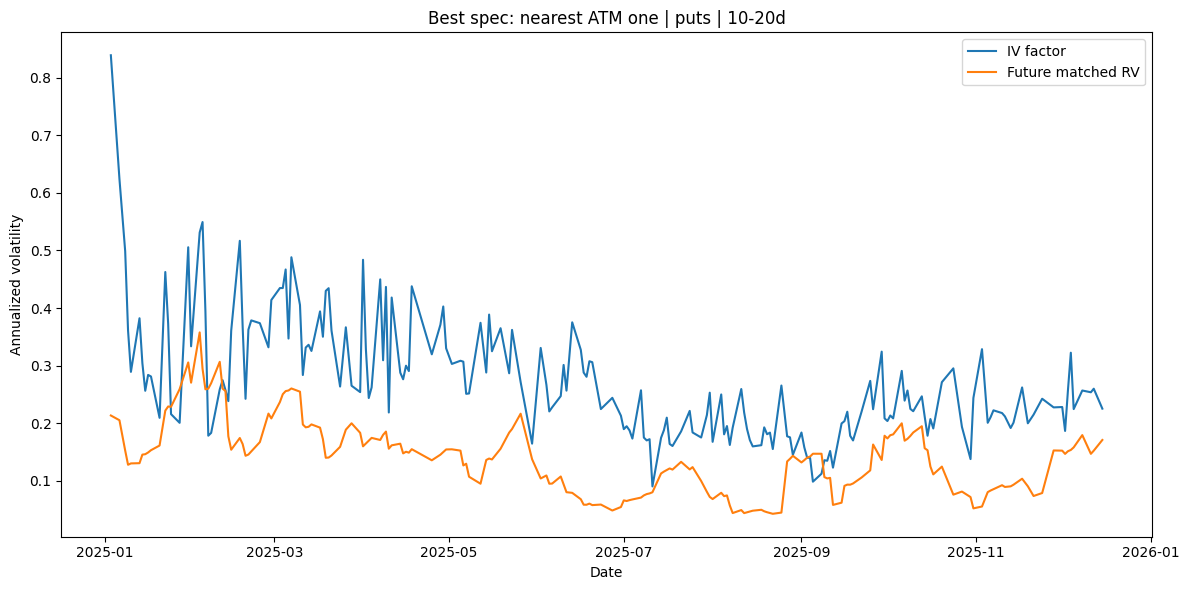

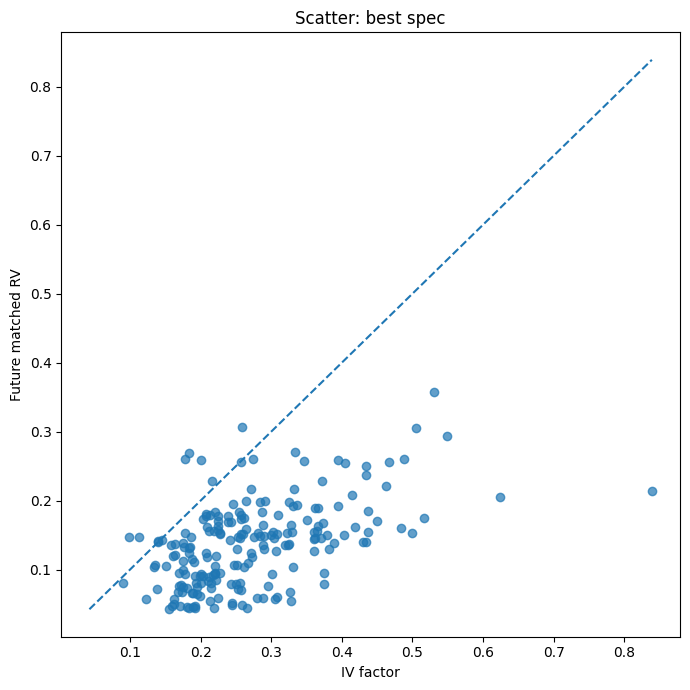

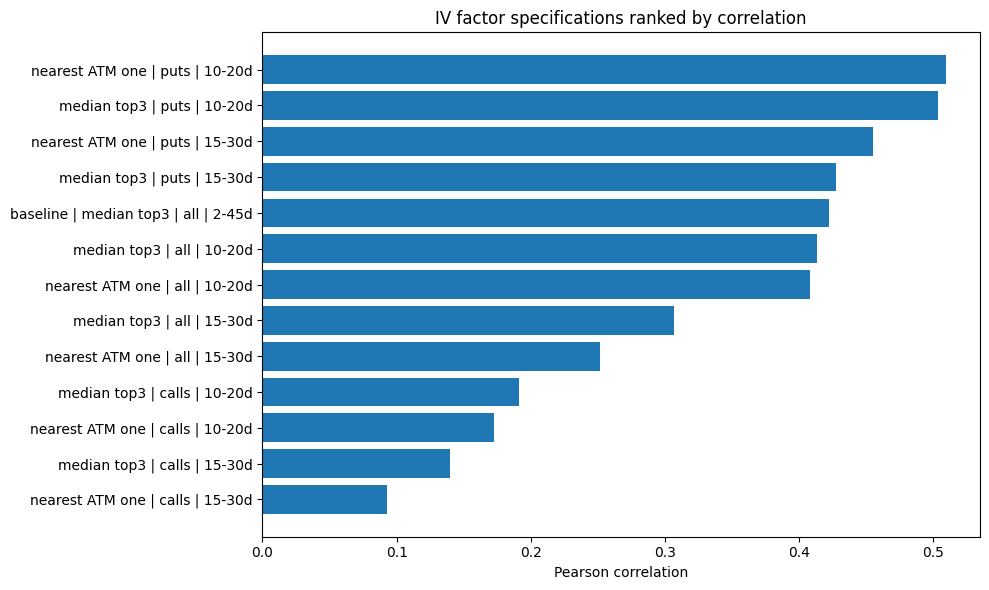

In [ ]:

plot_df = best_daily.dropna(subset=["iv_factor", "future_rv_matched"]).copy()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["trade_date"], plot_df["iv_factor"], label="IV factor")
plt.plot(plot_df["trade_date"], plot_df["future_rv_matched"], label="Future matched RV")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.title("Best spec: nearest ATM one | puts | 10-20d")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plt.scatter(plot_df["iv_factor"], plot_df["future_rv_matched"], alpha=0.7)
mn = min(plot_df["iv_factor"].min(), plot_df["future_rv_matched"].min())
mx = max(plot_df["iv_factor"].max(), plot_df["future_rv_matched"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("IV factor")
plt.ylabel("Future matched RV")
plt.title("Scatter: best spec")
plt.tight_layout()
plt.show()

plot_rank = results_df.sort_values("pearson_corr", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(plot_rank["spec"], plot_rank["pearson_corr"])
plt.xlabel("Pearson correlation")
plt.title("IV factor specifications ranked by correlation")
plt.tight_layout()
plt.show()


In [ ]:
import re
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq

OPT_FILE = "/content/cny_options_2025_final.csv"
SPOT_FILE = "/content/new_cny_rub_target_OHLC.csv"
SHIBOR_FILE = "/content/Shibor_Historical_Data.xlsx"
RUB_RATE_FILE = "/content/RC_F01_01_2025_T31_12_2025.xlsx"

OUT_MERGED = "/content/cny_options_2025_merged_filled.csv"
OUT_IV = "/content/cnyp_options_with_iv.csv"
OUT_DAILY = "/content/best_iv_dataset_puts_10_20d_nearest_one.csv"
OUT_MODEL = "/content/best_iv_dataset_for_model.csv"
OUT_METRICS = "/content/best_iv_metrics_puts_10_20d_nearest_one.csv"

def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).strip().lower())

def to_num(s):
    return pd.to_numeric(
        s.astype(str).str.replace(",", ".", regex=False).str.replace("%", "", regex=False),
        errors="coerce"
    )

def find_col(df, aliases_exact=None, aliases_contains=None, required=True):
    aliases_exact = aliases_exact or []
    aliases_contains = aliases_contains or []

    name_map = {c: norm_name(c) for c in df.columns}
    for alias in aliases_exact:
        na = norm_name(alias)
        for c, nc in name_map.items():
            if nc == na:
                return c
    for alias in aliases_contains:
        na = norm_name(alias)
        for c, nc in name_map.items():
            if na in nc:
                return c

    if required:
        raise KeyError(
            f"Не нашла колонку. exact={aliases_exact}, contains={aliases_contains}\n"
            f"Доступные колонки:\n{list(df.columns)}"
        )
    return None

def load_excel_any(path):
    try:
        return pd.read_excel(path)
    except Exception:
        return pd.read_excel(path, engine="openpyxl")

def pick_first_existing(paths):
    import os
    for p in paths:
        if os.path.exists(p):
            return p
    return None

opt = pd.read_csv(OPT_FILE)

trade_date_col = find_col(
    opt,
    aliases_exact=["trade_date", "date", "tradedate"],
    aliases_contains=["trade_date", "tradedate", "date"]
)
secid_col = find_col(
    opt,
    aliases_exact=["secid_raw", "secid", "symbol", "ticker"],
    aliases_contains=["secid", "symbol", "ticker"]
)

opt = opt.rename(columns={trade_date_col: "trade_date", secid_col: "secid_raw"})
opt["trade_date"] = pd.to_datetime(opt["trade_date"], errors="coerce")

opt = opt[opt["secid_raw"].astype(str).str.startswith("CNYP", na=False)].copy()

=expiration_col = find_col(
    opt,
    aliases_exact=["expiration_date", "expiry", "exp_date", "matdate", "maturity_date"],
    aliases_contains=["expiration", "expiry", "matdate", "maturity"],
    required=False
)
strike_col = find_col(
    opt,
    aliases_exact=["strike", "strike_price", "k"],
    aliases_contains=["strike"],
    required=False
)
option_type_col = find_col(
    opt,
    aliases_exact=["option_type", "cp", "type"],
    aliases_contains=["optiontype", "option_type", "cp"],
    required=False
)
settle_col = find_col(
    opt,
    aliases_exact=["settle_price", "settle", "settlement_price"],
    aliases_contains=["settle"],
    required=False
)
last_col = find_col(
    opt,
    aliases_exact=["last_trade_price", "last_price", "last", "close_price"],
    aliases_contains=["last", "closeprice"],
    required=False
)
first_col = find_col(
    opt,
    aliases_exact=["first_trade_price", "first_price", "first", "open_price"],
    aliases_contains=["first", "openprice"],
    required=False
)

volume_col = find_col(
    opt,
    aliases_exact=["volume", "vol", "trading_volume"],
    aliases_contains=["volume", "vol"],
    required=False
)
oi_col = find_col(
    opt,
    aliases_exact=["open_interest", "oi", "openinterest"],
    aliases_contains=["openinterest", "oi"],
    required=False
)

rename_map = {}
if expiration_col is not None:
    rename_map[expiration_col] = "expiration_date"
if strike_col is not None:
    rename_map[strike_col] = "strike"
if option_type_col is not None:
    rename_map[option_type_col] = "option_type"
if settle_col is not None:
    rename_map[settle_col] = "settle_price"
if last_col is not None:
    rename_map[last_col] = "last_trade_price"
if first_col is not None:
    rename_map[first_col] = "first_trade_price"
if volume_col is not None:
    rename_map[volume_col] = "volume"
if oi_col is not None:
    rename_map[oi_col] = "open_interest"

opt = opt.rename(columns=rename_map)

if "expiration_date" not in opt.columns:
    raise ValueError("Не нашла expiration_date / expiry в файле опционов.")
if "strike" not in opt.columns:
    raise ValueError("Не нашла strike в файле опционов.")
if "option_type" not in opt.columns:
    raise ValueError("Не нашла option_type в файле опционов.")

opt["expiration_date"] = pd.to_datetime(opt["expiration_date"], errors="coerce")
opt["strike"] = to_num(opt["strike"])
opt["volume"] = to_num(opt["volume"]) if "volume" in opt.columns else 0.0
opt["open_interest"] = to_num(opt["open_interest"]) if "open_interest" in opt.columns else 0.0
opt["option_type"] = opt["option_type"].astype(str).str.upper().str[0]

for c in ["settle_price", "last_trade_price", "first_trade_price"]:
    if c in opt.columns:
        opt[c] = to_num(opt[c])

opt["T_days"] = (opt["expiration_date"] - opt["trade_date"]).dt.days
opt["T"] = opt["T_days"] / 252.0

spot = pd.read_csv(SPOT_FILE)

spot_date_col = find_col(
    spot,
    aliases_exact=["trade_date", "date", "tradedate"],
    aliases_contains=["trade_date", "tradedate", "date"]
)
spot_close_col = find_col(
    spot,
    aliases_exact=["cnyrub_close", "close", "close_price", "price"],
    aliases_contains=["cnyrubclose", "close", "price"]
)

spot = spot.rename(columns={spot_date_col: "trade_date", spot_close_col: "cnyrub_close"})
spot["trade_date"] = pd.to_datetime(spot["trade_date"], errors="coerce")
spot["cnyrub_close"] = to_num(spot["cnyrub_close"])
spot = (
    spot[["trade_date", "cnyrub_close"]]
    .dropna()
    .drop_duplicates()
    .sort_values("trade_date")
    .reset_index(drop=True)
)

shibor_path = pick_first_existing([
    "/content/Shibor_Historical_Data.xlsx",
    "/content/Shibor_Historical_Data.xls"
])
if shibor_path is None:
    raise FileNotFoundError("Не нашла файл Shibor_Historical_Data.xlsx/.xls")

shibor = load_excel_any(shibor_path)

shibor_date_col = find_col(
    shibor,
    aliases_exact=["date", "trade_date"],
    aliases_contains=["date"]
)
shibor_1m_col = find_col(
    shibor,
    aliases_exact=["1M", "1M Shibor", "shibor_1m", "1_month", "1 month"],
    aliases_contains=["1m", "onemonth", "1month"]
)

shibor = shibor.rename(columns={shibor_date_col: "trade_date", shibor_1m_col: "r_cny_1m"})
shibor["trade_date"] = pd.to_datetime(shibor["trade_date"], errors="coerce")
shibor["r_cny_1m"] = to_num(shibor["r_cny_1m"])
shibor = (
    shibor[["trade_date", "r_cny_1m"]]
    .dropna()
    .drop_duplicates()
    .sort_values("trade_date")
    .reset_index(drop=True)
)

rub_path = pick_first_existing([
    "/content/RC_F01_01_2025_T31_12_2025.xlsx",
    "/content/RC_F01_01_2025_T31_12_2025.xls"
])
if rub_path is None:
    raise FileNotFoundError("Не нашла файл RC_F01_01_2025_T31_12_2025.xlsx/.xls")

rub = load_excel_any(rub_path)

rub_date_col = find_col(
    rub,
    aliases_exact=["date", "trade_date"],
    aliases_contains=["date"]
)

rub_1m_col = find_col(
    rub,
    aliases_exact=["1M", "1M rate", "r_rub_1m", "1_month", "1 month", "value"],
    aliases_contains=["1m", "onemonth", "1month", "value", "rate"],
    required=False
)

if rub_1m_col is None:
    tmp = rub.copy()
    tmp = tmp.drop(columns=[rub_date_col], errors="ignore")
    numeric_candidates = []
    for c in tmp.columns:
        s = to_num(tmp[c])
        if s.notna().sum() > 0:
            numeric_candidates.append(c)
    if not numeric_candidates:
        raise ValueError("Не смогла найти числовую колонку со ставкой RUB.")
    rub_1m_col = numeric_candidates[0]

rub = rub.rename(columns={rub_date_col: "trade_date", rub_1m_col: "r_rub_1m"})
rub["trade_date"] = pd.to_datetime(rub["trade_date"], errors="coerce")
rub["r_rub_1m"] = to_num(rub["r_rub_1m"])
rub = (
    rub[["trade_date", "r_rub_1m"]]
    .dropna()
    .drop_duplicates()
    .sort_values("trade_date")
    .reset_index(drop=True)
)

print("Detected columns:")
print("options trade_date:", trade_date_col)
print("options secid:", secid_col)
print("options expiration:", expiration_col)
print("options strike:", strike_col)
print("options option_type:", option_type_col)
print("spot close:", spot_close_col)
print("shibor 1m:", shibor_1m_col)
print("rub 1m:", rub_1m_col)

opt = opt.sort_values("trade_date").reset_index(drop=True)

opt = pd.merge_asof(
    opt,
    spot.sort_values("trade_date"),
    on="trade_date",
    direction="backward"
)
opt = pd.merge_asof(
    opt,
    shibor.sort_values("trade_date"),
    on="trade_date",
    direction="backward"
)
opt = pd.merge_asof(
    opt,
    rub.sort_values("trade_date"),
    on="trade_date",
    direction="backward"
)

opt["option_price"] = opt[
    [c for c in ["settle_price", "last_trade_price", "first_trade_price"] if c in opt.columns]
].bfill(axis=1).iloc[:, 0]

opt.to_csv(OUT_MERGED, index=False)

opt["S"] = to_num(opt["cnyrub_close"])
opt["K"] = to_num(opt["strike"])
opt["T"] = to_num(opt["T"])
opt["T_days"] = to_num(opt["T_days"])
opt["r_rub"] = to_num(opt["r_rub_1m"]) / 100.0
opt["r_cny"] = to_num(opt["r_cny_1m"]) / 100.0
opt["volume"] = to_num(opt["volume"]).fillna(0)
opt["open_interest"] = to_num(opt["open_interest"]).fillna(0)

opt = opt[
    opt["option_type"].isin(["C", "P"])
    & opt["option_price"].notna() & (opt["option_price"] > 0)
    & opt["S"].notna() & (opt["S"] > 0)
    & opt["K"].notna() & (opt["K"] > 0)
    & opt["T"].notna() & (opt["T"] > 0)
    & opt["T_days"].notna() & (opt["T_days"] > 0)
    & opt["r_rub"].notna()
    & opt["r_cny"].notna()
].copy()

def gk_price(S, K, T, rd, rf, sigma, cp):
    if sigma <= 0 or T <= 0 or S <= 0 or K <= 0:
        return np.nan

    vol_sqrt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (rd - rf + 0.5 * sigma**2) * T) / vol_sqrt
    d2 = d1 - vol_sqrt

    if cp == "C":
        return S * np.exp(-rf * T) * norm.cdf(d1) - K * np.exp(-rd * T) * norm.cdf(d2)
    else:
        return K * np.exp(-rd * T) * norm.cdf(-d2) - S * np.exp(-rf * T) * norm.cdf(-d1)

def implied_vol_gk(price, S, K, T, rd, rf, cp):
    if any(pd.isna(x) for x in [price, S, K, T, rd, rf]):
        return np.nan
    if price <= 0 or S <= 0 or K <= 0 or T <= 0 or cp not in ["C", "P"]:
        return np.nan

    call_lb = max(S * np.exp(-rf * T) - K * np.exp(-rd * T), 0.0)
    put_lb = max(K * np.exp(-rd * T) - S * np.exp(-rf * T), 0.0)
    lower = call_lb if cp == "C" else put_lb
    upper = S * np.exp(-rf * T) if cp == "C" else K * np.exp(-rd * T)

    if price < lower - 1e-10 or price > upper + 1e-10:
        return np.nan

    f = lambda sigma: gk_price(S, K, T, rd, rf, sigma, cp) - price

    try:
        return brentq(f, 1e-6, 5.0, maxiter=200)
    except Exception:
        return np.nan

opt["iv"] = opt.apply(
    lambda row: implied_vol_gk(
        price=row["option_price"],
        S=row["S"],
        K=row["K"],
        T=row["T"],
        rd=row["r_rub"],
        rf=row["r_cny"],
        cp=row["option_type"]
    ),
    axis=1
)

opt = opt[opt["iv"].notna() & (opt["iv"] > 0) & (opt["iv"] < 5)].copy()
opt.to_csv(OUT_IV, index=False)

best = opt[
    opt["T_days"].between(10, 20)
    & (opt["option_type"] == "P")
    & ((opt["volume"] > 0) | (opt["open_interest"] > 0))
].copy()

best["abs_log_moneyness"] = np.abs(np.log(best["K"] / best["S"]))
best["liq"] = best["volume"] + best["open_interest"]

def pick_one_contract(group):
    g = group.sort_values(
        ["abs_log_moneyness", "liq", "T_days"],
        ascending=[True, False, True]
    ).copy()
    row = g.iloc[0]

    return pd.Series({
        "trade_date": row["trade_date"],
        "secid_raw": row["secid_raw"],
        "option_type": row["option_type"],
        "expiration_date": row["expiration_date"],
        "strike": row["K"],
        "spot": row["S"],
        "iv_factor": row["iv"],
        "selected_T_days": int(round(row["T_days"])),
        "abs_log_moneyness": row["abs_log_moneyness"],
        "volume": row["volume"],
        "open_interest": row["open_interest"],
        "liq": row["liq"],
        "option_price": row["option_price"],
        "r_rub_1m": row["r_rub_1m"],
        "r_cny_1m": row["r_cny_1m"],
    })

daily_best = (
    best.groupby("trade_date")
    .apply(pick_one_contract)
    .reset_index(drop=True)
    .sort_values("trade_date")
    .reset_index(drop=True)
)

spot2 = (
    spot[["trade_date", "cnyrub_close"]]
    .drop_duplicates()
    .sort_values("trade_date")
    .copy()
)
spot2["log_ret"] = np.log(spot2["cnyrub_close"] / spot2["cnyrub_close"].shift(1))

spot_dates = spot2["trade_date"].tolist()
spot_rets = spot2["log_ret"].tolist()
date_to_idx = {d: i for i, d in enumerate(spot_dates)}

def future_realized_vol_for_date(trade_date, horizon):
    if pd.isna(trade_date) or pd.isna(horizon):
        return np.nan

    h = int(round(horizon))
    idx = date_to_idx.get(trade_date, None)
    if idx is None or h <= 0:
        return np.nan

    future_slice = spot_rets[idx + 1 : idx + 1 + h]
    if len(future_slice) < h:
        return np.nan

    future_slice = np.asarray(future_slice, dtype=float)
    if np.isnan(future_slice).any():
        return np.nan

    return np.sqrt(252.0 * np.mean(future_slice**2))

def future_realized_var_for_date(trade_date, horizon):
    if pd.isna(trade_date) or pd.isna(horizon):
        return np.nan

    h = int(round(horizon))
    idx = date_to_idx.get(trade_date, None)
    if idx is None or h <= 0:
        return np.nan

    future_slice = spot_rets[idx + 1 : idx + 1 + h]
    if len(future_slice) < h:
        return np.nan

    future_slice = np.asarray(future_slice, dtype=float)
    if np.isnan(future_slice).any():
        return np.nan

    return 252.0 * np.mean(future_slice**2)

daily_best["future_rv_matched"] = [
    future_realized_vol_for_date(d, h)
    for d, h in zip(daily_best["trade_date"], daily_best["selected_T_days"])
]
daily_best["future_var_matched"] = [
    future_realized_var_for_date(d, h)
    for d, h in zip(daily_best["trade_date"], daily_best["selected_T_days"])
]
daily_best["iv_factor_var"] = daily_best["iv_factor"] ** 2
daily_best["iv_minus_future_rv"] = daily_best["iv_factor"] - daily_best["future_rv_matched"]

tmp = daily_best[["iv_factor", "future_rv_matched"]].dropna().copy()
a = tmp["future_rv_matched"].values
p = tmp["iv_factor"].values
err = p - a

denom = np.sum((a - np.mean(a)) ** 2)
r2_like = 1 - np.sum((a - p) ** 2) / denom if denom > 0 else np.nan

a_var = a ** 2
p_var = p ** 2
mask = (a_var > 1e-12) & (p_var > 1e-12)
qlike_var = np.mean(np.log(p_var[mask]) + a_var[mask] / p_var[mask]) if mask.sum() > 0 else np.nan

metrics = pd.DataFrame([{
    "spec": "nearest ATM one | puts | 10-20d",
    "method": "nearest_one",
    "side": "P",
    "t_window": "10-20",
    "n_factor_days": len(daily_best),
    "avg_selected_T_days": daily_best["selected_T_days"].mean(),
    "median_selected_T_days": daily_best["selected_T_days"].median(),
    "avg_opts_used": 1.0,
    "n": len(tmp),
    "pearson_corr": pd.Series(a).corr(pd.Series(p), method="pearson"),
    "spearman_corr": pd.Series(a).corr(pd.Series(p), method="spearman"),
    "mae": np.mean(np.abs(err)),
    "rmse": np.sqrt(np.mean(err ** 2)),
    "mse": np.mean(err ** 2),
    "bias": np.mean(err),
    "r2_like": r2_like,
    "qlike_var": qlike_var,
}])

daily_best.to_csv(OUT_DAILY, index=False)

final_model_df = daily_best[
    ["trade_date", "secid_raw", "iv_factor", "selected_T_days", "future_rv_matched"]
].dropna().copy()
final_model_df.to_csv(OUT_MODEL, index=False)

metrics.to_csv(OUT_METRICS, index=False)

print("Saved:")
print(OUT_MERGED)
print(OUT_IV)
print(OUT_DAILY)
print(OUT_MODEL)
print(OUT_METRICS)

print("\nMetrics:")
display(metrics.round(6))

print("\nPreview:")
display(final_model_df.head(20))

/tmp/ipykernel_13712/1477707200.py:206: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  spot["trade_date"] = pd.to_datetime(spot["trade_date"], errors="coerce")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Detected columns:
options trade_date: trade_date
options secid: secid_raw
options expiration: expiration_date
options strike: strike
options option_type: option_type
spot close: Close
shibor 1m: 1M
rub 1m: 1 month
Saved:
/content/cny_options_2025_merged_filled.csv
/content/cnyp_options_with_iv.csv
/content/best_iv_dataset_puts_10_20d_nearest_one.csv
/content/best_iv_dataset_for_model.csv
/content/best_iv_metrics_puts_10_20d_nearest_one.csv

Metrics:


/tmp/ipykernel_13712/1477707200.py:455: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pick_one_contract)


,spec,method,side,t_window,n_factor_days,avg_selected_T_days,median_selected_T_days,avg_opts_used,n,pearson_corr,spearman_corr,mae,rmse,mse,bias,r2_like,qlike_var
0,nearest ATM one | puts | 10-20d,nearest_one,P,10-20,210,13.519048,14.0,1.0,203,0.506993,0.498174,0.108019,0.128036,0.016393,0.102482,-3.305332,-2.540065



Preview:


,trade_date,secid_raw,iv_factor,selected_T_days,future_rv_matched
0,2025-01-03,CNYP160125PE14.4,0.711761,13,0.213272
1,2025-01-06,CNYP160125PE13.8,0.528744,10,0.205031
2,2025-01-08,CNYP230125PE13.8,0.429015,15,0.152431
3,2025-01-09,CNYP230125PE13.8,0.315433,14,0.127632
4,2025-01-10,CNYP230125PE13.8,0.255552,13,0.130015
5,2025-01-13,CNYP230125PE14,0.331665,10,0.130405
6,2025-01-14,CNYP300125PE14,0.268691,16,0.145259
7,2025-01-15,CNYP300125PE14,0.229506,15,0.145996
8,2025-01-16,CNYP300125PE14,0.250821,14,0.148980
9,2025-01-17,CNYP300125PE14,0.249061,13,0.152933


Number of observations: 203
Pearson correlation:  0.506993
Spearman correlation: 0.498174


,n,pearson_corr,spearman_corr,mae,rmse,mse,bias,r2_like
0,203,0.506993,0.498174,0.108019,0.128036,0.016393,0.102482,-3.305332


,iv_factor,future_rv_matched
iv_factor,1.000000,0.506993
future_rv_matched,0.506993,1.000000


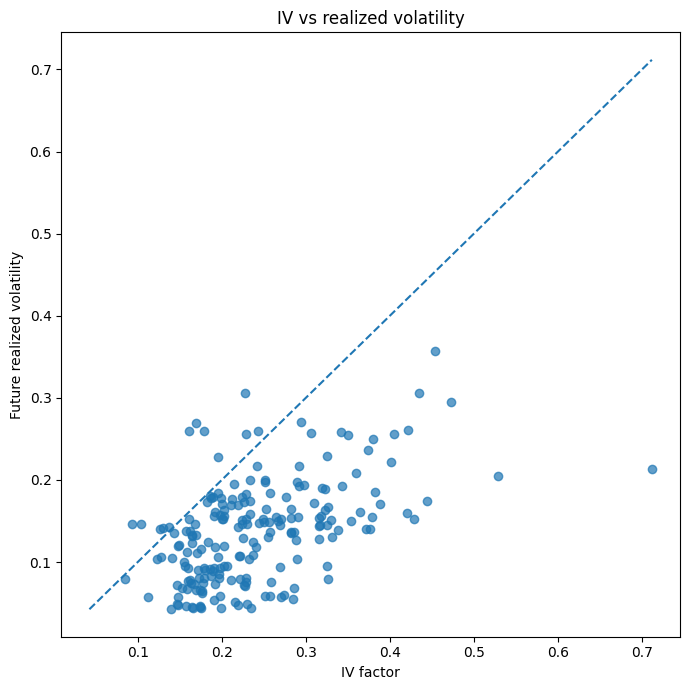

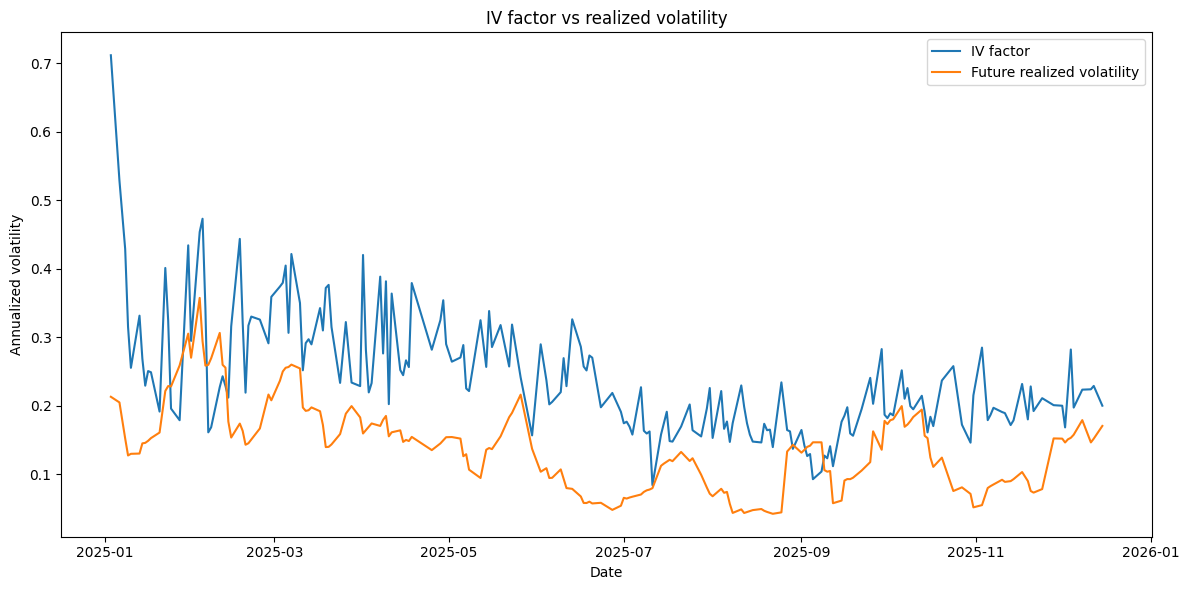

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/best_iv_dataset_for_model.csv")
df["trade_date"] = pd.to_datetime(df["trade_date"], errors="coerce")

df["iv_factor"] = pd.to_numeric(df["iv_factor"], errors="coerce")
df["future_rv_matched"] = pd.to_numeric(df["future_rv_matched"], errors="coerce")

tmp = df[["trade_date", "iv_factor", "future_rv_matched"]].dropna().copy()

print("Number of observations:", len(tmp))

pearson_corr = tmp["iv_factor"].corr(tmp["future_rv_matched"], method="pearson")
spearman_corr = tmp["iv_factor"].corr(tmp["future_rv_matched"], method="spearman")

print(f"Pearson correlation:  {pearson_corr:.6f}")
print(f"Spearman correlation: {spearman_corr:.6f}")

err = tmp["iv_factor"] - tmp["future_rv_matched"]

mae = np.mean(np.abs(err))
rmse = np.sqrt(np.mean(err**2))
mse = np.mean(err**2)
bias = np.mean(err)

denom = np.sum((tmp["future_rv_matched"] - tmp["future_rv_matched"].mean()) ** 2)
r2_like = 1 - np.sum((tmp["future_rv_matched"] - tmp["iv_factor"]) ** 2) / denom if denom > 0 else np.nan

metrics = pd.DataFrame([{
    "n": len(tmp),
    "pearson_corr": pearson_corr,
    "spearman_corr": spearman_corr,
    "mae": mae,
    "rmse": rmse,
    "mse": mse,
    "bias": bias,
    "r2_like": r2_like,
}])

display(metrics.round(6))

corr_matrix = tmp[["iv_factor", "future_rv_matched"]].corr()
display(corr_matrix.round(6))

plt.figure(figsize=(7, 7))
plt.scatter(tmp["iv_factor"], tmp["future_rv_matched"], alpha=0.7)
plt.xlabel("IV factor")
plt.ylabel("Future realized volatility")
plt.title("IV vs realized volatility")

mn = min(tmp["iv_factor"].min(), tmp["future_rv_matched"].min())
mx = max(tmp["iv_factor"].max(), tmp["future_rv_matched"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(tmp["trade_date"], tmp["iv_factor"], label="IV factor")
plt.plot(tmp["trade_date"], tmp["future_rv_matched"], label="Future realized volatility")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.title("IV factor vs realized volatility")
plt.legend()
plt.tight_layout()
plt.show()